In [ ]:
# https://drive.google.com/file/d/1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8/view?usp=sharing

In [ ]:
pip install gdown

In [ ]:
# Download the zip file from Google Drive
import gdown
import os

# link: https://drive.google.com/file/d/1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL/view?usp=sharing
file_id = '1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL
From (redirected): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL&confirm=t&uuid=47badb80-2ef9-4f2d-be83-a30306dcd4ae
To: /content/archive.zip
100%|██████████| 1.27G/1.27G [05:31<00:00, 3.83MB/s]


'archive.zip'

In [ ]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [ ]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.config', 'train', 'archive.zip', 'test', 'sample_data']


splitting data

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transformation

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root='train', transform=transform)

In [ ]:
# Split the full_dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [ ]:
from collections import Counter

# Count classes in train_dataset
train_class_counts = Counter()
for _, labels in train_loader:
    train_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Training Set:")
for class_idx, count in sorted(train_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

# Count classes in val_dataset
val_class_counts = Counter()
for _, labels in val_loader:
    val_class_counts.update(labels.cpu().numpy())

print("\nNumber of images per class in Validation Set:")
for class_idx, count in sorted(val_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Training Set:
  Class broadleaf (ID: 0): 644 images
  Class grass (ID: 1): 1986 images
  Class soil (ID: 2): 1811 images
  Class soybean (ID: 3): 4146 images

Number of images per class in Validation Set:
  Class broadleaf (ID: 0): 189 images
  Class grass (ID: 1): 478 images
  Class soil (ID: 2): 463 images
  Class soybean (ID: 3): 1017 images


MobilenetV2

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet50(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Sequential(
    nn.Linear(2048, 128),
    nn.ReLU(),

    nn.Linear(128, 4)
)

# model = model.to("cuda")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


Training loop

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import torch
from sklearn.metrics import f1_score, precision_score, recall_score

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):
    # ---- TRAIN ----
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)

    # ---- F1, Precision, Recall ----
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")
    print(f"F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print("-"*40)

Epoch 1
Train Loss: 0.2534, Train Acc: 0.9162
Val Loss: 0.1618, Val Acc: 0.9422
F1: 0.9435, Precision: 0.9485, Recall: 0.9422
----------------------------------------
Epoch 2
Train Loss: 0.1169, Train Acc: 0.9589
Val Loss: 0.0903, Val Acc: 0.9716
F1: 0.9715, Precision: 0.9715, Recall: 0.9716
----------------------------------------
Epoch 3
Train Loss: 0.0874, Train Acc: 0.9694
Val Loss: 0.1018, Val Acc: 0.9646
F1: 0.9650, Precision: 0.9663, Recall: 0.9646
----------------------------------------
Epoch 4
Train Loss: 0.0873, Train Acc: 0.9673
Val Loss: 0.0879, Val Acc: 0.9725
F1: 0.9724, Precision: 0.9725, Recall: 0.9725
----------------------------------------
Epoch 5
Train Loss: 0.0754, Train Acc: 0.9716
Val Loss: 0.0997, Val Acc: 0.9716
F1: 0.9715, Precision: 0.9722, Recall: 0.9716
----------------------------------------
Epoch 6
Train Loss: 0.0712, Train Acc: 0.9750
Val Loss: 0.0767, Val Acc: 0.9767
F1: 0.9768, Precision: 0.9770, Recall: 0.9767
---------------------------------------

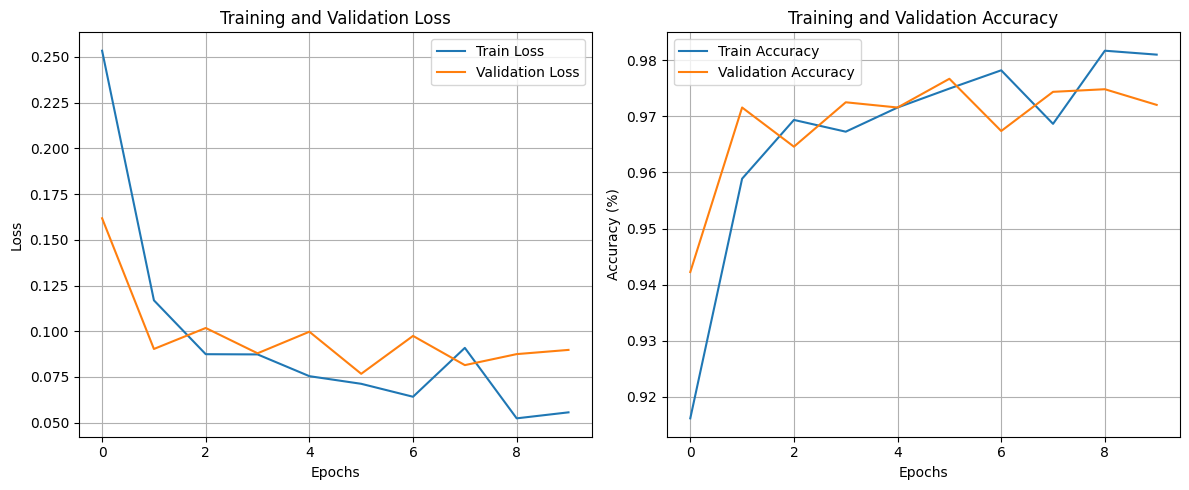

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)



plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
f1 = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print("Final Results:")
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Final Results:
F1 Score: 0.9718744371160837
Precision: 0.9723617766914315
Recall: 0.9720540288775035


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 23770820


Evaluation on Test Data

In [ ]:
test_dataset = datasets.ImageFolder(root='test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

# Count classes in test_dataset
test_class_counts = Counter()
for _, labels in test_loader:
    test_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Test Set:")
for class_idx, count in sorted(test_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Test Set:
  Class broadleaf (ID: 0): 358 images
  Class grass (ID: 1): 1056 images
  Class soil (ID: 2): 975 images
  Class soybean (ID: 3): 2213 images


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels

In [ ]:
preds, labels = evaluate_model(model, test_loader)

Test Loss: 0.0746
Test Accuracy: 97.41%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds, target_names=test_dataset.classes))

              precision    recall  f1-score   support

   broadleaf       0.91      0.94      0.92       358
       grass       0.99      0.93      0.96      1056
        soil       0.99      0.99      0.99       975
     soybean       0.97      0.99      0.98      2213

    accuracy                           0.97      4602
   macro avg       0.96      0.96      0.96      4602
weighted avg       0.97      0.97      0.97      4602



Latency

In [ ]:
import time

def measure_latency(model, loader, device, num_batches=64):
    model.eval()
    model.to(device)

    total_time = 0
    count = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            start = time.time()
            outputs = model(images)
            end = time.time()

            total_time += (end - start)
            count += 1

            if count >= num_batches:
                break

    avg_latency = total_time / count
    print(f"Average Latency per batch: {avg_latency:.6f} seconds")
    return avg_latency

In [ ]:
measure_latency(model, test_loader, device)

Average Latency per batch: 0.005740 seconds


0.005739863961935043

RAM usage

In [ ]:
import psutil
import os

def measure_ram():
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024**3  # GB
    print(f"RAM Usage: {mem:.4f} GB")
    return mem

In [ ]:
model.to("cpu")
model.eval()

images, _ = next(iter(test_loader))
images = images.to("cpu")

measure_ram()
with torch.no_grad():
    outputs = model(images)
measure_ram()

RAM Usage: 1.7781 GB
RAM Usage: 1.7781 GB


1.7780570983886719

In [ ]:
def get_model_size(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1024**2
    print(f"Model size: {size:.2f} MB")
    os.remove("temp.p")
    return size

In [ ]:
get_model_size(model)

Model size: 90.96 MB


90.96078777313232

Quantization

In [ ]:
import torch.quantization

quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},  # only linear layers quantized
    dtype=torch.qint8
)

/tmp/ipykernel_8010/956005537.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [ ]:
device = torch.device("cpu")
model.to(device)
quantized_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
quantized_model.to("cpu")
quantized_model.eval()
images = images.to("cpu")
measure_ram()
with torch.no_grad():
    outputs = quantized_model(images)
measure_ram()

RAM Usage: 1.7781 GB
RAM Usage: 1.7781 GB


1.7780570983886719

In [ ]:
preds,labels=evaluate_model(quantized_model, test_loader)

Test Loss: 0.0773
Test Accuracy: 97.24%


Measurements

In [ ]:
print("FP32 Model:")
measure_latency(model, test_loader, device)
get_model_size(model)

print("\nINT8 Quantized Model:")
measure_latency(quantized_model, test_loader, device)
get_model_size(quantized_model)

FP32 Model:
Average Latency per batch: 0.091662 seconds
Model size: 90.96 MB

INT8 Quantized Model:
Average Latency per batch: 0.087746 seconds
Model size: 90.21 MB


90.210768699646

Saving the models

In [ ]:
torch.save(model.state_dict(), "RESNETmodel_fp32.pth")

In [ ]:
torch.save(quantized_model.state_dict(), "RESNETmodel_int8.pth")

In [ ]:
from google.colab import files

files.download("RESNETmodel_fp32.pth")
files.download("RESNETmodel_int8.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>